# 🎯 Forex XGBoost Trading Filter — Complete Playbook

**Pipeline:** Data → Features → Labels → Walk-Forward Training → Live Inference → Backtest → Risk Management

**Prerequisites:** `pip install pandas numpy xgboost scikit-learn joblib matplotlib seaborn oandapyV20`

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
import warnings
from typing import Dict, List, Tuple
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from datetime import datetime

# OANDA
import oandapyV20
from oandapyV20.endpoints.instruments import InstrumentsCandles

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ All imports loaded')

✅ All imports loaded


## ⚙️ Configuration

Set your OANDA credentials and trading parameters here.

In [9]:
# ═══════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════

# OANDA Credentials (replace with your own)
OANDA_ACCOUNT_ID = 'YOUR_ACCOUNT_ID'
OANDA_TOKEN = 'YOUR_ACCESS_TOKEN'
OANDA_ENV = 'practice'  # or 'live'

# Trading Parameters
INSTRUMENT = 'EUR_USD'
GRANULARITY = 'H1'
DIRECTION = 'long'

# Risk Parameters
RISK_MULTIPLE = 1.0
REWARD_MULTIPLE = 2.0
MAX_BARS = 20
ATR_PERIOD = 14

# Model Parameters
TRAIN_WINDOW = 3000
TEST_WINDOW = 500
STEP_SIZE = 500
THRESHOLD = 0.6

# Feature Lookbacks
LOOKBACKS = [5, 10, 20, 50]

print(f"📊 {INSTRUMENT} | {GRANULARITY} | {DIRECTION}")
print(f"🎯 Risk:{RISK_MULTIPLE}R | Reward:{REWARD_MULTIPLE}R | Threshold:{THRESHOLD}")

📊 EUR_USD | H1 | long
🎯 Risk:1.0R | Reward:2.0R | Threshold:0.6


## 🔧 Layer 1: Feature Engineering

Compute technical indicators and statistical features from OHLCV data. **Note:** `atr_14` is explicitly computed for risk-based labels and visualization.

In [10]:
class ForexFeatureEngineer:
    """Feature engineering for XGBoost forex filter."""
    
    def __init__(self, lookback_periods: List[int] = None, atr_period: int = 14):
        self.lookbacks = lookback_periods or [5, 10, 20, 50]
        self.atr_period = atr_period
    
    def compute_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        # Explicit ATR for risk calculations (labels + viz)
        df[f'atr_{self.atr_period}'] = self._atr(df, self.atr_period)
        for period in self.lookbacks:
            df[f'ema_{period}'] = df['close'].ewm(span=period, adjust=False).mean()
            df[f'sma_{period}'] = df['close'].rolling(window=period).mean()
            df[f'close_dist_ema_{period}'] = (df['close'] - df[f'ema_{period}']) / df[f'ema_{period}']
            df[f'atr_{period}'] = self._atr(df, period)
            df[f'volatility_{period}'] = df['close'].rolling(period).std() / df['close'].rolling(period).mean()
            df[f'momentum_{period}'] = df['close'].pct_change(period)
            df[f'roc_{period}'] = (df['close'] - df['close'].shift(period)) / df['close'].shift(period)
            df[f'hl_position_{period}'] = (df['close'] - df['low'].rolling(period).min()) / (
                df['high'].rolling(period).max() - df['low'].rolling(period).min() + 1e-9)
        
        df['body_size'] = abs(df['close'] - df['open']) / df['open']
        df['upper_wick'] = (df['high'] - df[['close','open']].max(axis=1)) / df['open']
        df['lower_wick'] = (df[['close','open']].min(axis=1) - df['low']) / df['open']
        df['range'] = (df['high'] - df['low']) / df['low']
        df['bullish'] = (df['close'] > df['open']).astype(int)
        
        if 'volume' in df.columns and df['volume'].notna().any():
            df['volume_sma_20'] = df['volume'].rolling(20).mean()
            df['volume_ratio'] = df['volume'] / df['volume_sma_20']
            df['volume_momentum'] = df['volume'].pct_change(5)
        
        df['hour'] = df.index.hour
        df['day_of_week'] = df.index.dayofweek
        df['is_london'] = ((df['hour'] >= 8) & (df['hour'] <= 16)).astype(int)
        df['is_ny'] = ((df['hour'] >= 13) & (df['hour'] <= 21)).astype(int)
        return df
    
    def _atr(self, df: pd.DataFrame, period: int) -> pd.Series:
        high_low = df['high'] - df['low']
        high_close = abs(df['high'] - df['close'].shift())
        low_close = abs(df['low'] - df['close'].shift())
        tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        return tr.rolling(window=period).mean()
    
    def get_feature_columns(self, df: pd.DataFrame) -> List[str]:
        exclude = ['open', 'high', 'low', 'close', 'volume', 'target']
        return [c for c in df.columns if c not in exclude]

print('✅ ForexFeatureEngineer defined')

✅ ForexFeatureEngineer defined


## 🏷️ Layer 2: Label Generation

Target: Will price move 2R profit before hitting 1R loss within N bars?

In [11]:
class LabelGenerator:
    """Generate binary labels for XGBoost training."""
    
    def __init__(self, risk_multiple=1.0, reward_multiple=2.0, max_bars=20, atr_period=14):
        self.risk_multiple = risk_multiple
        self.reward_multiple = reward_multiple
        self.max_bars = max_bars
        self.atr_period = atr_period
    
    def generate_labels(self, df: pd.DataFrame, direction='long') -> pd.Series:
        atr = self._atr(df, self.atr_period)
        labels = pd.Series(index=df.index, dtype=float)
        labels[:] = -1
        for i in range(len(df) - self.max_bars):
            if pd.isna(atr.iloc[i]): continue
            entry = df['close'].iloc[i]
            atr_val = atr.iloc[i]
            if direction == 'long':
                sl = entry - atr_val * self.risk_multiple
                tp = entry + atr_val * self.reward_multiple
            else:
                sl = entry + atr_val * self.risk_multiple
                tp = entry - atr_val * self.reward_multiple
            future = df.iloc[i+1:i+1+self.max_bars]
            if direction == 'long':
                stop_hit = (future['low'] <= sl).any()
                target_hit = (future['high'] >= tp).any()
            else:
                stop_hit = (future['high'] >= sl).any()
                target_hit = (future['low'] <= tp).any()
            if target_hit and not stop_hit:
                labels.iloc[i] = 1
            elif stop_hit and not target_hit:
                labels.iloc[i] = 0
            elif stop_hit and target_hit:
                labels.iloc[i] = self._first_hit(future, sl, tp, direction)
            else:
                labels.iloc[i] = 0
        return labels
    
    def _first_hit(self, future, stop, target, direction):
        for _, bar in future.iterrows():
            if direction == 'long':
                if bar['low'] <= stop: return 0
                if bar['high'] >= target: return 1
            else:
                if bar['high'] >= stop: return 0
                if bar['low'] <= target: return 1
        return 0
    
    def _atr(self, df, period):
        high_low = df['high'] - df['low']
        high_close = abs(df['high'] - df['close'].shift())
        low_close = abs(df['low'] - df['close'].shift())
        tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        return tr.rolling(window=period).mean()

print('✅ LabelGenerator defined')

✅ LabelGenerator defined


## 📥 Layer 3: Data Ingestion

Fetch from OANDA API or use synthetic data for demonstration.

In [12]:
def fetch_oanda_data(instrument, granularity, count=5000, token=None):
    if token is None or token == 'YOUR_ACCESS_TOKEN':
        print('⚠️ Using synthetic demo data. Replace OANDA_TOKEN for live data.')
        np.random.seed(42)
        n = count
        dates = pd.date_range(end=datetime.now(), periods=n, freq='H')
        returns = np.random.normal(0.0001, 0.001, n)
        close = 1.0850 * np.exp(np.cumsum(returns))
        high = close * (1 + abs(np.random.normal(0, 0.001, n)))
        low = close * (1 - abs(np.random.normal(0, 0.001, n)))
        open_p = close * (1 + np.random.normal(0, 0.0005, n))
        volume = np.random.randint(1000, 10000, n)
        df = pd.DataFrame({'open': open_p, 'high': high, 'low': low, 'close': close, 'volume': volume}, index=dates)
        return df
    
    client = oandapyV20.API(access_token=token, environment=OANDA_ENV)
    params = {'count': count, 'granularity': granularity, 'price': 'M'}
    r = InstrumentsCandles(instrument=instrument, params=params)
    client.request(r)
    candles = r.response['candles']
    data = []
    for c in candles:
        if not c['complete']: continue
        data.append({'time': pd.to_datetime(c['time']), 'open': float(c['mid']['o']),
                     'high': float(c['mid']['h']), 'low': float(c['mid']['l']),
                     'close': float(c['mid']['c']), 'volume': int(c['volume'])})
    return pd.DataFrame(data).set_index('time')

df_raw = fetch_oanda_data(INSTRUMENT, GRANULARITY, count=5000, token=OANDA_TOKEN)
print(f"📈 Loaded {len(df_raw)} bars | {df_raw.index[0]} → {df_raw.index[-1]}")
df_raw.tail()

⚠️ Using synthetic demo data. Replace OANDA_TOKEN for live data.
📈 Loaded 5000 bars | 2026-01-01 02:06:16.707346 → 2026-07-28 09:06:16.707346


,open,high,low,close,volume
2026-07-28 05:06:16.707346,1.832350,1.834378,1.830328,1.831995,6952
2026-07-28 06:06:16.707346,1.834744,1.837146,1.831213,1.833482,9132
2026-07-28 07:06:16.707346,1.839730,1.840679,1.836968,1.839382,1885
2026-07-28 08:06:16.707346,1.842630,1.841966,1.839425,1.841053,8492
2026-07-28 09:06:16.707346,1.838186,1.840862,1.839393,1.839676,5843


In [13]:
fe = ForexFeatureEngineer(lookback_periods=LOOKBACKS, atr_period=ATR_PERIOD)
lg = LabelGenerator(risk_multiple=RISK_MULTIPLE, reward_multiple=REWARD_MULTIPLE,
                    max_bars=MAX_BARS, atr_period=ATR_PERIOD)
df = fe.compute_features(df_raw)
df['target'] = lg.generate_labels(df, direction=DIRECTION)
feature_cols = fe.get_feature_columns(df)
df_clean = df.dropna(subset=feature_cols + ['target'])
df_clean = df_clean[df_clean['target'].isin([0, 1])]
print(f"✅ Clean: {len(df_clean)} samples | {len(feature_cols)} features")
print(f"🎯 Distribution:\n{df_clean['target'].value_counts(normalize=True)}")
print(f"📊 Available ATR columns: {[c for c in df_clean.columns if 'atr_' in c]}")
df_clean[['close','target'] + feature_cols[:5]].tail()

✅ Clean: 4930 samples | 45 features
🎯 Distribution:
target
0.0    0.591684
1.0    0.408316
Name: proportion, dtype: float64
📊 Available ATR columns: ['atr_14', 'atr_5', 'atr_10', 'atr_20', 'atr_50']


,close,target,atr_14,ema_5,sma_5,close_dist_ema_5,atr_5
2026-07-27 09:06:16.707346,1.823851,0.0,0.002943,1.827480,1.829002,-0.001986,0.003520
2026-07-27 10:06:16.707346,1.826549,0.0,0.003227,1.827170,1.827515,-0.000340,0.004318
2026-07-27 11:06:16.707346,1.826943,0.0,0.003308,1.827094,1.826440,-0.000083,0.003973
2026-07-27 12:06:16.707346,1.827838,0.0,0.003364,1.827342,1.826271,0.000271,0.003914
2026-07-27 13:06:16.707346,1.823966,0.0,0.003619,1.826217,1.825830,-0.001232,0.003945


## 📊 Layer 4: Exploratory Visualization

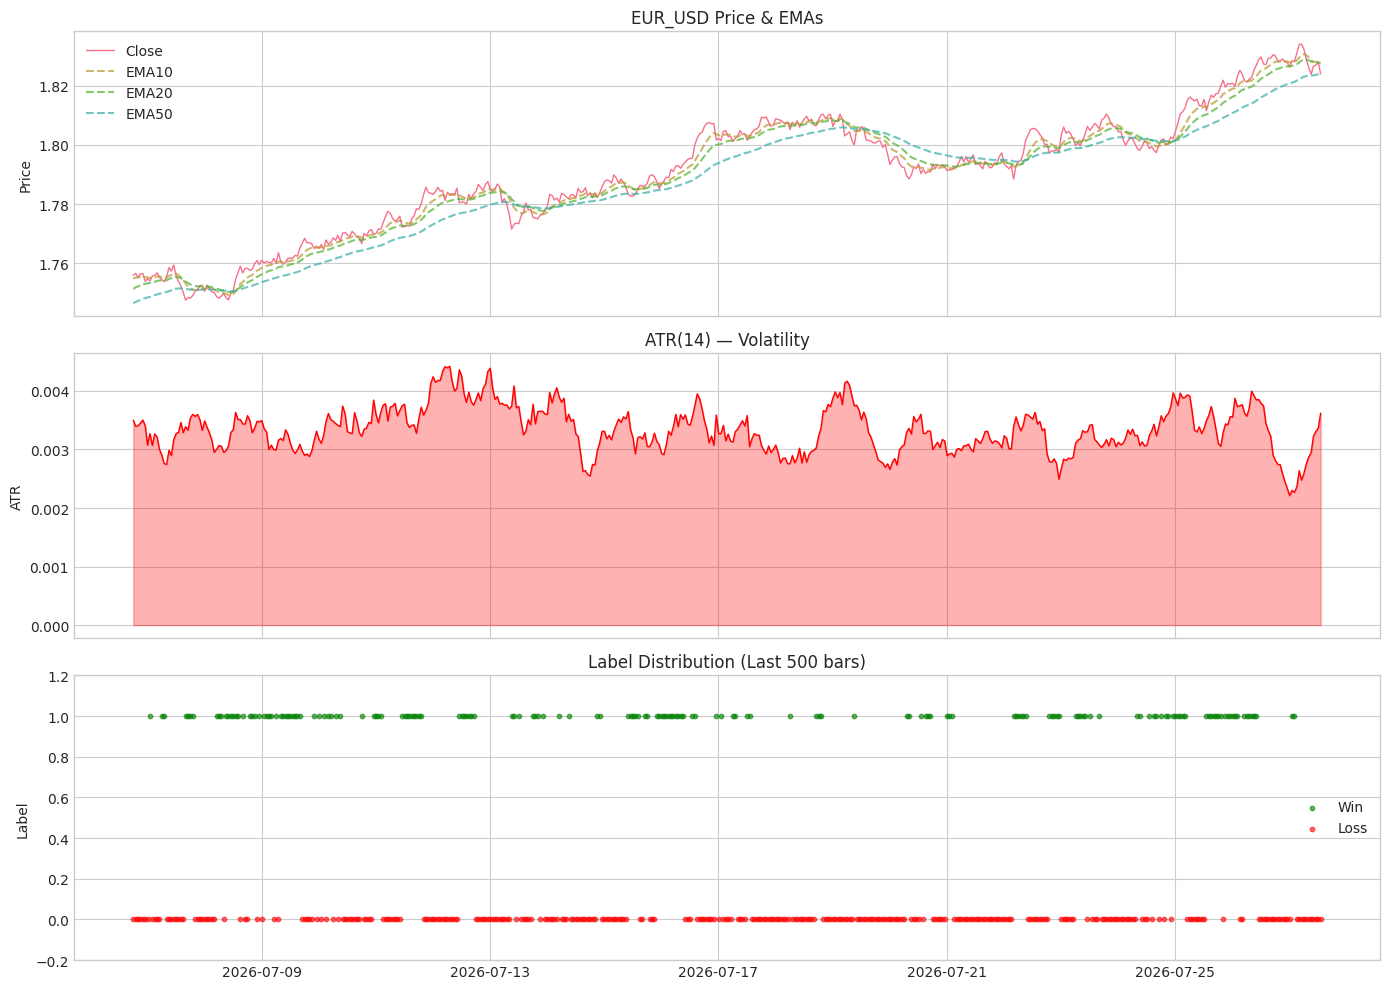

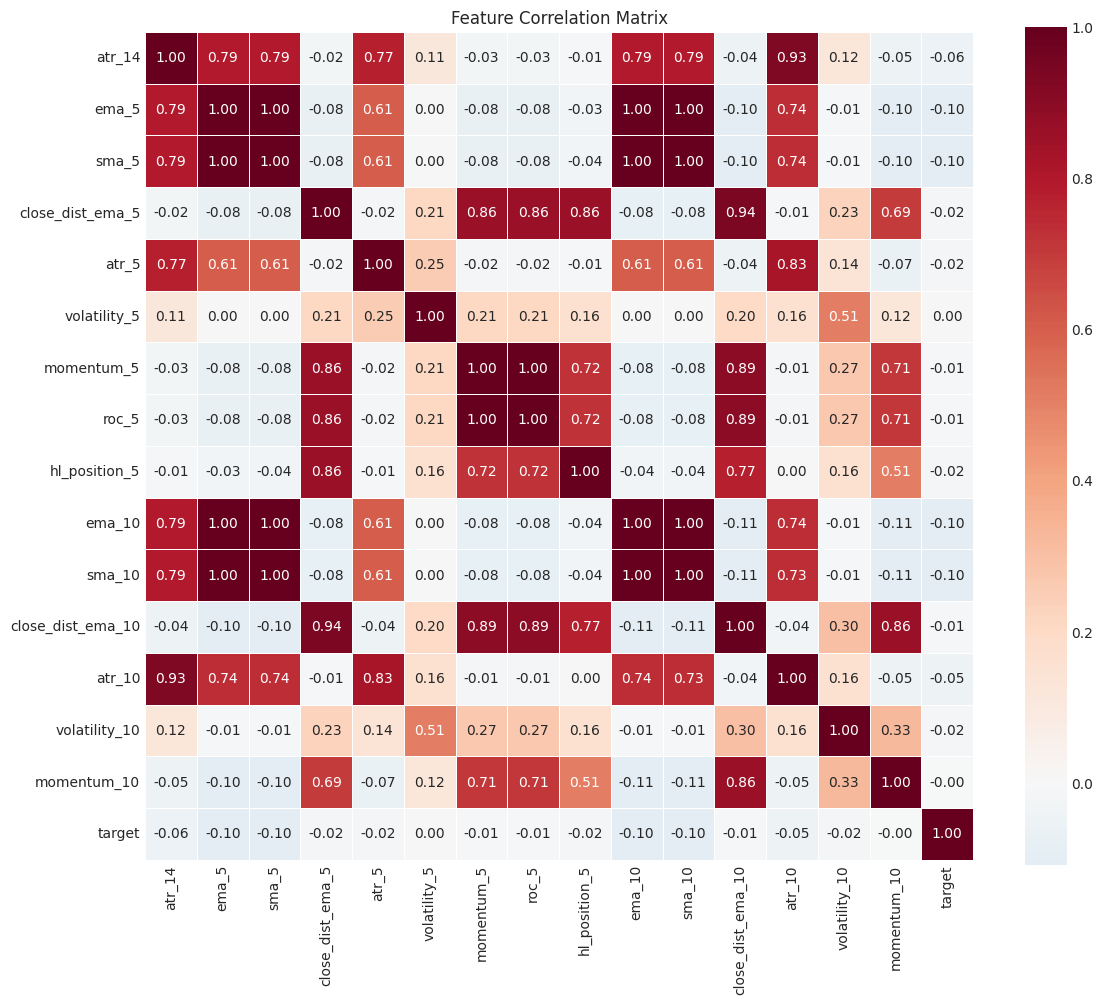

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1 = axes[0]
ax1.plot(df_clean.index[-500:], df_clean['close'].iloc[-500:], label='Close', linewidth=1)
for period in [10, 20, 50]:
    ax1.plot(df_clean.index[-500:], df_clean[f'ema_{period}'].iloc[-500:], label=f'EMA{period}', alpha=0.7, linestyle='--')
ax1.set_title(f'{INSTRUMENT} Price & EMAs')
ax1.legend(loc='upper left')
ax1.set_ylabel('Price')

ax2 = axes[1]
atr_col = f'atr_{ATR_PERIOD}'  # e.g. 'atr_14'
ax2.fill_between(df_clean.index[-500:], df_clean[atr_col].iloc[-500:], alpha=0.3, color='red')
ax2.plot(df_clean.index[-500:], df_clean[atr_col].iloc[-500:], color='red', linewidth=1)
ax2.set_title(f'ATR({ATR_PERIOD}) — Volatility')
ax2.set_ylabel('ATR')

ax3 = axes[2]
labels_s = df_clean['target'].iloc[-500:]
wins = labels_s[labels_s == 1].index
losses = labels_s[labels_s == 0].index
ax3.scatter(wins, [1]*len(wins), color='green', alpha=0.6, s=10, label='Win')
ax3.scatter(losses, [0]*len(losses), color='red', alpha=0.6, s=10, label='Loss')
ax3.set_title('Label Distribution (Last 500 bars)')
ax3.set_ylabel('Label')
ax3.set_ylim(-0.2, 1.2)
ax3.legend()
plt.tight_layout()
plt.show()

# Correlation heatmap
top_features = feature_cols[:15]
corr = df_clean[top_features + ['target']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 🤖 Layer 5: Walk-Forward XGBoost Training

Train on rolling windows to prevent look-ahead bias and overfitting.

In [15]:
class WalkForwardXGB:
    def __init__(self, train_window=3000, test_window=500, step_size=500, threshold=0.6):
        self.train_window = train_window
        self.test_window = test_window
        self.step_size = step_size
        self.threshold = threshold
        self.model = None
        self.feature_cols = None
        self.results = []
        self.models = []
    
    def train(self, df: pd.DataFrame, feature_cols: List[str]):
        self.feature_cols = feature_cols
        df = df.reset_index(drop=True)
        n = len(df)
        best_trade_acc = 0
        for start in range(0, n - self.train_window - self.test_window, self.step_size):
            train_s, train_e = start, start + self.train_window
            test_s, test_e = train_e, train_e + self.test_window
            X_train = df.iloc[train_s:train_e][feature_cols]
            y_train = df.iloc[train_s:train_e]['target']
            X_test = df.iloc[test_s:test_e][feature_cols]
            y_test = df.iloc[test_s:test_e]['target']
            pos = (y_train == 1).sum()
            neg = (y_train == 0).sum()
            scale_weight = neg / pos if pos > 0 else 1
            model = xgb.XGBClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_weight, eval_metric='logloss',
                random_state=42, n_jobs=-1)
            model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
                      early_stopping_rounds=30, verbose=False)
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]
            trades = y_proba >= self.threshold
            trade_acc = (y_test[trades] == 1).mean() if trades.sum() > 0 else 0
            trade_prec = precision_score(y_test[trades], y_pred[trades], zero_division=0) if trades.sum() > 0 else 0
            self.results.append({
                'fold': len(self.results), 'train_start': train_s, 'test_start': test_s,
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, zero_division=0),
                'f1': f1_score(y_test, y_pred, zero_division=0),
                'trade_accuracy': trade_acc, 'trade_precision': trade_prec,
                'trade_rate': trades.mean(), 'n_trades': int(trades.sum()),
                'avg_proba': y_proba.mean(), 'best_iter': model.best_iteration})
            self.models.append(model)
            if trade_acc > best_trade_acc:
                best_trade_acc = trade_acc
                self.model = model
                joblib.dump(model, 'best_xgb_model.pkl')
        return pd.DataFrame(self.results)
    
    def feature_importance(self) -> pd.DataFrame:
        imp = pd.DataFrame({'feature': self.feature_cols, 'importance': self.model.feature_importances_})
        return imp.sort_values('importance', ascending=False)
    
    def predict(self, X: pd.DataFrame) -> Tuple[int, float]:
        proba = self.model.predict_proba(X)[:, 1][0]
        return (1 if proba >= self.threshold else 0), float(proba)

wfx = WalkForwardXGB(train_window=TRAIN_WINDOW, test_window=TEST_WINDOW,
                     step_size=STEP_SIZE, threshold=THRESHOLD)
print('🚀 Starting walk-forward training...')
results_df = wfx.train(df_clean, feature_cols)
print(f"✅ {len(results_df)} folds complete")
results_df

🚀 Starting walk-forward training...


AttributeError: module 'xgboost' has no attribute 'XGBClassifier'

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ax = axes[0, 0]
colors = ['green' if x > 0.55 else 'orange' if x > 0.5 else 'red' for x in results_df['trade_accuracy']]
ax.bar(results_df['fold'], results_df['trade_accuracy'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0.5, color='red', linestyle='--', label='Random')
ax.axhline(y=0.55, color='green', linestyle='--', label='Breakeven')
ax.set_title('Trade Accuracy per Fold')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim(0, 1)

ax = axes[0, 1]
ax.bar(results_df['fold'], results_df['n_trades'], color='steelblue', alpha=0.7, edgecolor='black')
ax.set_title('Trades per Fold')
ax.set_xlabel('Fold')
ax.set_ylabel('Trades')

ax = axes[0, 2]
ax.plot(results_df['fold'], results_df['trade_rate'], marker='o', color='purple', linewidth=2)
ax.fill_between(results_df['fold'], results_df['trade_rate'], alpha=0.2, color='purple')
ax.set_title('Signal Rate')
ax.set_xlabel('Fold')
ax.set_ylabel('Fraction')
ax.set_ylim(0, 1)

ax = axes[1, 0]
ax.scatter(results_df['accuracy'], results_df['trade_accuracy'], s=100, alpha=0.6, edgecolors='black')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
ax.set_xlabel('Overall Accuracy')
ax.set_ylabel('Trade Accuracy')
ax.set_title('Overall vs Trade Accuracy')
ax.set_xlim(0.4, 0.8)
ax.set_ylim(0.4, 0.8)

ax = axes[1, 1]
ax.plot(results_df['fold'], results_df['trade_accuracy'].rolling(3, min_periods=1).mean(),
        marker='o', color='darkgreen', linewidth=2, label='3-Fold MA')
ax.plot(results_df['fold'], results_df['trade_accuracy'], 'o-', alpha=0.3, color='gray')
ax.axhline(y=0.55, color='red', linestyle='--')
ax.set_title('Rolling Trade Accuracy')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.legend()

ax = axes[1, 2]
ax.axis('off')
summary = {
    'Metric': ['Mean Trade Acc', 'Std Trade Acc', 'Best Fold', 'Worst Fold', 'Avg Trades/Fold', 'Mean Signal Rate', 'Overall Precision'],
    'Value': [f"{results_df['trade_accuracy'].mean():.3f}", f"{results_df['trade_accuracy'].std():.3f}",
              f"{results_df['trade_accuracy'].max():.3f}", f"{results_df['trade_accuracy'].min():.3f}",
              f"{results_df['n_trades'].mean():.0f}", f"{results_df['trade_rate'].mean():.3f}",
              f"{results_df['precision'].mean():.3f}"]}
table = ax.table(cellText=[[summary['Metric'][i], summary['Value'][i]] for i in range(len(summary['Metric']))],
                 colLabels=['Metric', 'Value'], cellLoc='center', loc='center', colColours=['#4472C4']*2)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
for i in range(len(summary['Metric'])+1):
    table[(i, 0)].set_facecolor('#D6E4F0')
    table[(i, 1)].set_facecolor('#F2F2F2')
ax.set_title('Summary', pad=20)

plt.suptitle(f'Walk-Forward: {INSTRUMENT} {GRANULARITY} ({DIRECTION})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 Mean Trade Accuracy: {results_df['trade_accuracy'].mean():.3f}")
print(f"   Signal Rate: {results_df['trade_rate'].mean():.1%} of bars")

In [ ]:
imp_df = wfx.feature_importance().head(20)
plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(imp_df)))
bars = plt.barh(range(len(imp_df)), imp_df['importance'], color=colors, edgecolor='black')
plt.yticks(range(len(imp_df)), imp_df['feature'])
plt.xlabel('Importance')
plt.title(f'Top 20 Features — {INSTRUMENT}')
plt.gca().invert_yaxis()
for bar, val in zip(bars, imp_df['importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print(imp_df.head(10).to_string(index=False))

## ⚡ Layer 6: Live Inference

In [ ]:
class LiveXGBFilter:
    def __init__(self, model_path: str, instrument: str, granularity='H1',
                 token=None, lookbacks=None, atr_period=14):
        self.model = joblib.load(model_path)
        self.fe = ForexFeatureEngineer(lookback_periods=lookbacks or [5,10,20,50], atr_period=atr_period)
        self.instrument = instrument
        self.granularity = granularity
        self.token = token
        self.feature_cols = None
        if token and token != 'YOUR_ACCESS_TOKEN':
            self.client = oandapyV20.API(access_token=token, environment=OANDA_ENV)
        else:
            self.client = None
    
    def fetch_candles(self, count=200):
        if self.client is None: raise ValueError('OANDA client not initialized')
        params = {'count': count, 'granularity': self.granularity, 'price': 'M'}
        r = InstrumentsCandles(instrument=self.instrument, params=params)
        self.client.request(r)
        data = []
        for c in r.response['candles']:
            if not c['complete']: continue
            data.append({'time': pd.to_datetime(c['time']), 'open': float(c['mid']['o']),
                         'high': float(c['mid']['h']), 'low': float(c['mid']['l']),
                         'close': float(c['mid']['c']), 'volume': int(c['volume'])})
        return pd.DataFrame(data).set_index('time')
    
    def generate_signal(self, df=None, threshold=0.6):
        if df is None: df = self.fetch_candles(count=200)
        df = self.fe.compute_features(df)
        if self.feature_cols is None:
            self.feature_cols = self.fe.get_feature_columns(df)
        latest = df.iloc[-2]
        if latest[self.feature_cols].isna().any():
            return {'signal': 0, 'error': 'Insufficient data'}
        X = latest[self.feature_cols].values.reshape(1, -1)
        proba = self.model.predict_proba(X)[:, 1][0]
        atr = latest.get(f'atr_{self.fe.atr_period}', df[f'atr_{self.fe.atr_period}'].iloc[-5:].mean())
        return {
            'signal': 1 if proba >= threshold else 0,
            'probability': float(proba), 'threshold': threshold,
            'timestamp': latest.name.isoformat(), 'instrument': self.instrument,
            'close': float(latest['close']), 'atr_14': float(atr),
            'suggested_stop': float(latest['close'] - atr * RISK_MULTIPLE) if DIRECTION == 'long' else float(latest['close'] + atr * RISK_MULTIPLE),
            'suggested_target': float(latest['close'] + atr * REWARD_MULTIPLE) if DIRECTION == 'long' else float(latest['close'] - atr * REWARD_MULTIPLE),
            'features': {k: float(v) for k, v in latest[self.feature_cols].items()}}

live_filter = LiveXGBFilter('best_xgb_model.pkl', INSTRUMENT, GRANULARITY, OANDA_TOKEN, LOOKBACKS, ATR_PERIOD)
signal = live_filter.generate_signal(df=df_clean.iloc[-200:], threshold=THRESHOLD)
print('═'*50)
print('🎯 LIVE SIGNAL')
print('═'*50)
print(f"Instrument:    {signal.get('instrument', 'N/A')}")
print(f"Timestamp:     {signal.get('timestamp', 'N/A')}")
print(f"Close:         {signal.get('close', 0):.5f}")
print(f"Signal:        {'🟢 TAKE TRADE' if signal['signal']==1 else '🔴 NO TRADE'}")
print(f"Probability:   {signal.get('probability', 0):.3f}")
print(f"ATR:           {signal.get('atr_14', 0):.5f}")
print(f"Suggested SL:  {signal.get('suggested_stop', 0):.5f}")
print(f"Suggested TP:  {signal.get('suggested_target', 0):.5f}")
print('═'*50)

## 📈 Layer 7: Backtest Simulation

In [ ]:
class XGBBacktester:
    def __init__(self, initial_capital=10000, risk_per_trade=0.01):
        self.initial_capital = initial_capital
        self.risk_per_trade = risk_per_trade
    
    def run(self, df, model, feature_cols, threshold=0.6, direction='long'):
        equity = self.initial_capital
        trades = []
        for i in range(50, len(df) - MAX_BARS):
            row = df.iloc[i]
            if row[feature_cols].isna().any(): continue
            X = row[feature_cols].values.reshape(1, -1)
            proba = model.predict_proba(X)[:, 1][0]
            if proba < threshold:
                trades.append({'bar': i, 'equity': equity, 'action': 'hold'})
                continue
            entry = row['close']
            atr = row.get(f'atr_{ATR_PERIOD}', df[f'atr_{ATR_PERIOD}'].iloc[max(0,i-5):i].mean())
            if direction == 'long':
                sl = entry - atr * RISK_MULTIPLE
                tp = entry + atr * REWARD_MULTIPLE
            else:
                sl = entry + atr * RISK_MULTIPLE
                tp = entry - atr * REWARD_MULTIPLE
            future = df.iloc[i+1:i+1+MAX_BARS]
            if direction == 'long':
                stop_hit = (future['low'] <= sl).any()
                target_hit = (future['high'] >= tp).any()
            else:
                stop_hit = (future['high'] >= sl).any()
                target_hit = (future['low'] <= tp).any()
            if target_hit and not stop_hit:
                result, pnl_pct = 'win', REWARD_MULTIPLE * self.risk_per_trade
            elif stop_hit and not target_hit:
                result, pnl_pct = 'loss', -RISK_MULTIPLE * self.risk_per_trade
            elif stop_hit and target_hit:
                result, pnl_pct = self._check_first(future, sl, tp, direction)
            else:
                result, pnl_pct = 'timeout', 0
            equity = equity * (1 + pnl_pct)
            trades.append({'bar': i, 'timestamp': row.name, 'equity': equity, 'action': result,
                           'pnl_pct': pnl_pct * 100, 'probability': proba,
                           'entry': entry, 'sl': sl, 'tp': tp})
        return pd.DataFrame(trades)
    
    def _check_first(self, future, sl, tp, direction):
        for _, bar in future.iterrows():
            if direction == 'long':
                if bar['low'] <= sl: return 'loss', -RISK_MULTIPLE * self.risk_per_trade
                if bar['high'] >= tp: return 'win', REWARD_MULTIPLE * self.risk_per_trade
            else:
                if bar['high'] >= sl: return 'loss', -RISK_MULTIPLE * self.risk_per_trade
                if bar['low'] <= tp: return 'win', REWARD_MULTIPLE * self.risk_per_trade
        return 'timeout', 0

bt = XGBBacktester(initial_capital=10000, risk_per_trade=0.01)
trade_log = bt.run(df_clean, wfx.model, feature_cols, threshold=THRESHOLD, direction=DIRECTION)
actual_trades = trade_log[trade_log['action'] != 'hold']
print(f"📊 Backtest: {len(actual_trades)} trades | Win rate: {(actual_trades['action']=='win').mean():.1%}")
print(f"   Final Equity: ${trade_log['equity'].iloc[-1]:,.2f} | Return: {(trade_log['equity'].iloc[-1]/10000-1)*100:.2f}%")
print(f"   Max DD: {((trade_log['equity']/trade_log['equity'].cummax())-1).min()*100:.2f}%")
actual_trades.tail(10)

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

ax = axes[0]
ax.plot(trade_log['timestamp'], trade_log['equity'], linewidth=1.5, color='darkblue')
ax.fill_between(trade_log['timestamp'], trade_log['equity'], 10000,
                alpha=0.2, color='green' if trade_log['equity'].iloc[-1] > 10000 else 'red')
ax.axhline(y=10000, color='black', linestyle='--', alpha=0.5)
ax.set_title(f'Equity Curve — {INSTRUMENT}')
ax.set_ylabel('Equity ($)')

ax = axes[1]
cummax = trade_log['equity'].cummax()
drawdown = (trade_log['equity'] - cummax) / cummax * 100
ax.fill_between(trade_log['timestamp'], drawdown, 0, alpha=0.3, color='red')
ax.plot(trade_log['timestamp'], drawdown, color='red', linewidth=1)
ax.set_title('Drawdown (%)')
ax.set_ylabel('Drawdown %')

ax = axes[2]
pnls = actual_trades['pnl_pct'].dropna()
colors = ['green' if x > 0 else 'red' for x in pnls]
ax.bar(range(len(pnls)), pnls, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Trade PnL (%)')
ax.set_xlabel('Trade')
ax.set_ylabel('PnL %')
plt.tight_layout()
plt.show()

wins = actual_trades[actual_trades['action'] == 'win']['pnl_pct']
losses = actual_trades[actual_trades['action'] == 'loss']['pnl_pct']
print(f"Avg Win: {wins.mean():.2f}% | Avg Loss: {losses.mean():.2f}%")
print(f"Best: {pnls.max():.2f}% | Worst: {pnls.min():.2f}%")
print(f"Profit Factor: {abs(wins.sum()/losses.sum()):.2f} | Expectancy: {pnls.mean():.3f}%")

## 🛡️ Layer 8: Risk Management

In [ ]:
class RiskManager:
    def __init__(self, max_risk_per_trade=0.01, max_daily_drawdown=0.05,
                 max_open_trades=3, kill_switch=True):
        self.max_risk = max_risk_per_trade
        self.max_daily_dd = max_daily_drawdown
        self.max_open = max_open_trades
        self.kill_switch = kill_switch
        self.daily_pnl = 0
        self.open_trades = 0
        self.trade_history = []
        self.killed = False
    
    def can_trade(self, account_balance, current_dd) -> Tuple[bool, str]:
        if self.killed: return False, 'KILL_SWITCH: Halted'
        if current_dd >= self.max_daily_dd:
            if self.kill_switch: self.killed = True
            return False, f'Daily DD limit: {current_dd:.2%}'
        if self.open_trades >= self.max_open:
            return False, f'Max open: {self.open_trades}'
        return True, 'OK'
    
    def position_size(self, balance, entry, stop_loss) -> float:
        risk_amount = balance * self.max_risk
        price_risk = abs(entry - stop_loss)
        if price_risk == 0: return 0
        return round(risk_amount / price_risk, 0)
    
    def record(self, entry, stop, target, units, result='open'):
        self.trade_history.append({'entry': entry, 'stop': stop, 'target': target,
                                   'units': units, 'result': result, 'timestamp': datetime.now()})
        self.open_trades += 1 if result == 'open' else -1
        self.open_trades = max(0, self.open_trades)
    
    def reset_daily(self):
        self.daily_pnl = 0; self.killed = False; print('🌅 Daily reset')

rm = RiskManager(max_risk_per_trade=0.01, max_daily_drawdown=0.05)
balance, entry, sl = 10000, 1.0850, 1.0820
can_trade, reason = rm.can_trade(balance, current_dd=0.02)
units = rm.position_size(balance, entry, sl)
print(f"Risk Check: {can_trade} ({reason})")
print(f"Position: {units:,.0f} units | Risk: ${balance*0.01:,.2f}")

## 🔗 Layer 9: Complete Integration

Full pipeline: Data → Features → Model → Signal → Risk → Execution.

In [ ]:
class ForexTradingSystem:
    def __init__(self, config):
        self.config = config
        self.fe = ForexFeatureEngineer(lookbacks=config.get('lookbacks', [5,10,20,50]),
                                       atr_period=config.get('atr_period', 14))
        self.rm = RiskManager(max_risk_per_trade=config.get('max_risk', 0.01),
                              max_daily_drawdown=config.get('max_dd', 0.05))
        self.model = None
        self.feature_cols = None
        token = config.get('oanda_token')
        if token and token != 'YOUR_ACCESS_TOKEN':
            self.client = oandapyV20.API(access_token=token, environment=config.get('env', 'practice'))
        else:
            self.client = None
    
    def train(self, df, direction='long'):
        df = self.fe.compute_features(df)
        lg = LabelGenerator(risk_multiple=self.config.get('risk_mult', 1.0),
                            reward_multiple=self.config.get('reward_mult', 2.0),
                            max_bars=self.config.get('max_bars', 20),
                            atr_period=self.config.get('atr_period', 14))
        df['target'] = lg.generate_labels(df, direction)
        self.feature_cols = self.fe.get_feature_columns(df)
        df_clean = df.dropna(subset=self.feature_cols + ['target'])
        df_clean = df_clean[df_clean['target'].isin([0, 1])]
        wfx = WalkForwardXGB(train_window=self.config.get('train_window', 3000),
                             test_window=self.config.get('test_window', 500),
                             step_size=self.config.get('step_size', 500),
                             threshold=self.config.get('threshold', 0.6))
        results = wfx.train(df_clean, self.feature_cols)
        self.model = wfx.model
        return results, wfx
    
    def get_signal(self, df=None, threshold=None):
        if threshold is None: threshold = self.config.get('threshold', 0.6)
        if df is None and self.client:
            params = {'count': 200, 'granularity': self.config.get('granularity', 'H1'), 'price': 'M'}
            r = InstrumentsCandles(instrument=self.config.get('instrument', 'EUR_USD'), params=params)
            self.client.request(r)
            data = []
            for c in r.response['candles']:
                if not c['complete']: continue
                data.append({'time': pd.to_datetime(c['time']), 'open': float(c['mid']['o']),
                             'high': float(c['mid']['h']), 'low': float(c['mid']['l']),
                             'close': float(c['mid']['c']), 'volume': int(c['volume'])})
            df = pd.DataFrame(data).set_index('time')
        df = self.fe.compute_features(df)
        latest = df.iloc[-2]
        if latest[self.feature_cols].isna().any():
            return {'signal': 0, 'error': 'Insufficient data'}
        X = latest[self.feature_cols].values.reshape(1, -1)
        proba = self.model.predict_proba(X)[:, 1][0]
        atr = latest.get(f'atr_{self.config.get("atr_period", 14)}',
                         df[f'atr_{self.config.get("atr_period", 14)}'].iloc[-5:].mean())
        direction = self.config.get('direction', 'long')
        return {
            'signal': 1 if proba >= threshold else 0,
            'probability': float(proba), 'timestamp': latest.name.isoformat(),
            'close': float(latest['close']), 'atr': float(atr),
            'stop': float(latest['close'] - atr * self.config.get('risk_mult', 1.0)) if direction == 'long' else float(latest['close'] + atr * self.config.get('risk_mult', 1.0)),
            'target': float(latest['close'] + atr * self.config.get('reward_mult', 2.0)) if direction == 'long' else float(latest['close'] - atr * self.config.get('reward_mult', 2.0))}
    
    def execute(self, signal, balance):
        can_trade, reason = self.rm.can_trade(balance, current_dd=0.0)
        if not can_trade:
            return {'executed': False, 'reason': reason}
        if signal['signal'] != 1:
            return {'executed': False, 'reason': 'No signal'}
        units = self.rm.position_size(balance, signal['close'], signal['stop'])
        self.rm.record(signal['close'], signal['stop'], signal['target'], units, 'open')
        return {'executed': True, 'units': units, 'entry': signal['close'],
                'stop': signal['stop'], 'target': signal['target'],
                'probability': signal['probability']}

config = {
    'instrument': 'EUR_USD', 'granularity': 'H1', 'direction': 'long',
    'oanda_token': OANDA_TOKEN, 'env': OANDA_ENV,
    'lookbacks': [5, 10, 20, 50], 'threshold': 0.6, 'atr_period': 14,
    'risk_mult': 1.0, 'reward_mult': 2.0, 'max_bars': 20,
    'train_window': 3000, 'test_window': 500, 'step_size': 500,
    'max_risk': 0.01, 'max_dd': 0.05
}

system = ForexTradingSystem(config)
print('✅ ForexTradingSystem initialized')
print('Use system.train(df) → system.get_signal() → system.execute()')

## 🚀 Next Steps

1. **Replace synthetic data** with real OANDA credentials
2. **Paper trade** for 2-4 weeks before live deployment
3. **Add base strategy** (EMA crossover) — only take XGB signals when aligned
4. **Monitor model drift** — retrain monthly if performance degrades
5. **Add logging** — persist all predictions, trades, and P&L to your database

## ⚠️ Risk Warning

- Past performance ≠ future results
- Forex carries significant risk of loss
- Never trade with money you cannot afford to lose
- Start with 0.01 lots (micro) even after paper trading success